In [1]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from matplotlib.animation import FFMpegWriter
from tqdm.notebook import tqdm
import astropy.io.fits as fits
from pathlib import Path, PosixPath
import math
from scipy.interpolate import interp1d
from speclite import filters
import scipy.integrate as integrate
from shackhartmann import MySquareShackHartmannWavefrontSensorOptics
from transmitted_power import transmitted_power

In [2]:
# some telescope parameters

telescope_diameter = 0.8 #m
focal_length = 5.6 #m
platescale = 206265 / focal_length #arcsec/m
fov_sci = 2 # arcsec

spider_width = 0.02 # m this is a guess
num_spiders = 4
central_obscuration = 0.1558 # meter
central_obscuration_ratio = central_obscuration / telescope_diameter
oversizing_factor = 16 / 16
area_aperture = math.pi*(telescope_diameter/2)**2 - math.pi*(central_obscuration/2)**2 - (telescope_diameter-central_obscuration)*spider_width*num_spiders # m^2

num_pupil_pixels = 64 * oversizing_factor
pupil_diameter = telescope_diameter * oversizing_factor

In [3]:
# transmission loss parameters

n_telescope_mirrors = 3
n_ao_mirrors = 7

target_spectrum_file = Path('LEO_spectrum.fits') # can be .fits or .csv
telescope_coating_file = Path('protected_aluminium_reflectance.csv') #microns
ao_coating_file = Path('protected_aluminium_reflectance.csv')
qe_file = Path('qe_curve.csv') # angstr; asked ChatGPT to make arrays from an image of QE curve for Oxford Instr. OCAM2K camera 

wfs_spectral_band = 'r'
wfs_filter = filters.load_filter(f'sdss2010-{wfs_spectral_band}')

In [4]:
# make a telescope pupil

pupil_grid = make_pupil_grid(num_pupil_pixels, diameter=pupil_diameter)
pupil_aperture_generator = make_obstructed_circular_aperture(telescope_diameter, 
                                                             central_obscuration_ratio, 
                                                             num_spiders=num_spiders, 
                                                             spider_width=spider_width)
telescope_pupil = evaluate_supersampled(pupil_aperture_generator, pupil_grid, 4)

In [5]:
# get target light

if target_spectrum_file.suffix == '.fits':
    hdu = fits.open(target_spectrum_file)
    target_wavelength, target_flux = hdu[1].data['WAVELENGTH'], hdu[1].data['FLUX'] #angstroms, FLAM (erg * s^-1 * cm^-2 * angstr^-1)
elif target_spectrum_file.suffix == '.csv':
    target_data = np.loadtxt(target_spectrum_file, delimiter=',', skiprows=1)
    target_wavelength, target_flux = target_data[:, 0], target_data[:, 1] 
target_power = target_flux*area_aperture*1e4

In [6]:
# reduce target light transmission due to surfaces in telescope and AO

wavelength_crop1, transmitted_power_telescope = transmitted_power(wavelength = target_wavelength, 
                                                                  in_power = target_power,
                                                                  transmission_file = telescope_coating_file,
                                                                  n_surfaces = n_telescope_mirrors)

wavelength_crop2, transmitted_power_ao = transmitted_power(wavelength = wavelength_crop1, 
                                                         in_power = transmitted_power_telescope,
                                                         transmission_file = ao_coating_file,
                                                         n_surfaces = n_ao_mirrors)

In [7]:
# make wavefronts for after propagation through telescope & AO surfaces

wavefronts_target = []
for i, wlen in enumerate(wavelength_crop2):
    wf = Wavefront(telescope_pupil, wlen*1e-10) # HCIPy wavefronts take wavelengths in meters only!
    wf.total_power = transmitted_power_ao[i]
    wavefronts_target.append(wf)

In [50]:
# split wavefronts for WFS and Science Camera

# WFS beam
wavelength_wfs = 7000e-10 # m. - reference, central wavelength
wfs_bandwidth = 1000e-10
wfs_beamsplit = 0.4 # between 0 (no light) and 1 (all of the light)

# science camera beam
wavelength_sci = 5500e-10 # m - central wavelength
sci_bandwidth = 100e-10

# make wavefront arrays
wfs_min, wfs_max = wavelength_wfs - wfs_bandwidth/2, wavelength_wfs + wfs_bandwidth/2
wfs_wavefronts = np.array(wavefronts_target)[(target_wavelength*1e-10 > wfs_min) & (target_wavelength*1e-10 < wfs_max)]
for wf in wfs_wavefronts:
    wf.total_power *= wfs_beamsplit
wfs_wls = [wf.wavelength*1e10 for wf in wfs_wavefronts] # convert wavelengths back to angstrom for plotting
wfs_power = [wf.total_power for wf in wfs_wavefronts]

sci_min, sci_max = wavelength_sci - sci_bandwidth/2, wavelength_sci + sci_bandwidth/2
sci_wavefronts = np.array(wavefronts_target)[(target_wavelength*1e-10 > sci_min) & (target_wavelength*1e-10 < sci_max)]
for wf in sci_wavefronts:
    if (wf.wavelength < wfs_max) and (wf.wavelength > wfs_min):
        print("overlap")
        wf.total_power *= (1 - wfs_beamsplit)
sci_wls = np.array([wf.wavelength*1e10 for wf in sci_wavefronts]) # convert wavelengths back to angstrom for plotting
sci_power = np.array([wf.total_power for wf in sci_wavefronts])

In [51]:
# make focal plane

spatial_res = sci_max * focal_length / telescope_diameter # all variables use meters
num_airy = fov_sci/platescale / spatial_res
sci_cam_px_size = 2.9e-6 # meters / px, assuming same pixel size as current LEO camera
q = math.ceil(spatial_res / sci_cam_px_size)
focal_grid = make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=spatial_res)
# q = number of pixels between rings, num_airy = number of rings that should be visible

print(f"expected number of visible airy disks: {round(num_airy,1)}, expected spatial extent of focal plane: {round(spatial_res*num_airy/1e-6, 1)}µm")

expected number of visible airy disks: 14.0, expected spatial extent of focal plane: 54.3µm


In [52]:
# make an atmosphere

seeing = 1 # arcsec @ 500nm (convention) -> r0 = 10.1cm
outer_scale = 40 # meter
tau0 = 0.01 # seconds

fried_parameter = seeing_to_fried_parameter(seeing)
Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
velocity = 0.314 * fried_parameter / tau0

prop = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)

# put a camera in the Science beam

sci_camera = NoiselessDetector(focal_grid)
sci_camera2 = NoiselessDetector(focal_grid)

  0%|          | 0/10000 [00:00<?, ?it/s]

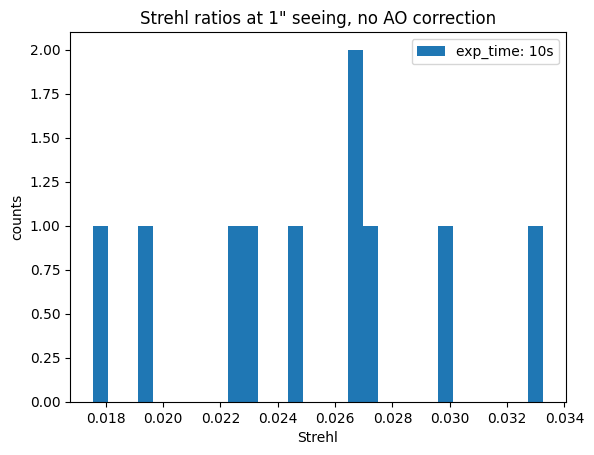

[]


In [59]:
sci_exp_times = [10]
strehls = [] 
t_atmos = 0.01

layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity)

psf_ref = 0
turb_psf = 0

for sci_exp_time in sci_exp_times:

    strehls = []
    layer.reset()

    for step in tqdm(range(10000)):
    
        layer.t = t_atmos*step
        
        for wf in sci_wavefronts:
            
            sci_camera.integrate(prop.forward(wf), t_atmos)
            sci_camera2.integrate(prop.forward(layer(wf)), t_atmos)
            
        if int(layer.t*1000) % int(sci_exp_time*1000) == 0: # modulo behaves weird with decimals

            psf_ref = 0
            turb_psf = 0
            
            psf_ref = sci_camera.read_out()
            turb_psf = sci_camera2.read_out()
        
            strehl = get_strehl_from_focal(turb_psf, psf_ref)
            strehls.append(strehl)

    plt.hist(strehls, bins=30, label=f'exp_time: {sci_exp_time}s')
    
plt.title(f'Strehl ratios at {seeing}" seeing, no AO correction')
plt.legend()
plt.xlabel('Strehl')
plt.ylabel('counts')
plt.show()
print(strehls)

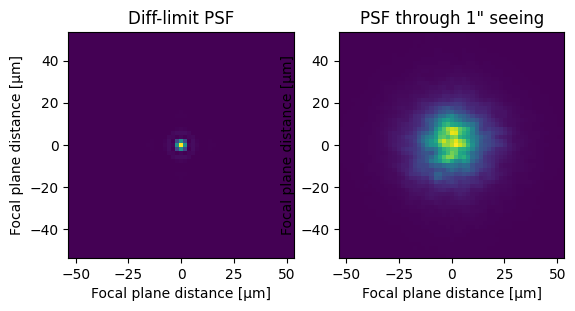

In [60]:
plt.subplot(1,2,1)
plt.title('Diff-limit PSF')
imshow_field(psf_ref, grid_units=1e-6)
plt.xlabel('Focal plane distance [µm]')
plt.ylabel('Focal plane distance [µm]')

plt.subplot(1,2,2)
plt.title(f'PSF through {seeing}" seeing')
imshow_field(turb_psf, grid_units=1e-6)#, vmin = -6, vmax=0, grid_units=1e-6)
plt.xlabel('Focal plane distance [µm]')
plt.ylabel('Focal plane distance [µm]')
#plt.colorbar()

plt.show()